In [2]:
import json
import pickle
import re
import unicodedata
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import sklearn_crfsuite
from seqeval.metrics import classification_report, f1_score, precision_score, recall_score

plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13})

### Access the data

In [ ]:
data_dir  = Path('../../datasets/processed_data')
split_dir = Path('../../datasets/split_data')

with open(data_dir / 'processed.pkl', 'rb') as f:
    processed = pickle.load(f)

# Load pre-split CRF datasets
with open(data_dir / 'crf_train.pkl', 'rb') as f:
    crf_train = pickle.load(f)
with open(data_dir / 'crf_val.pkl', 'rb') as f:
    crf_val = pickle.load(f)
with open(data_dir / 'crf_test.pkl', 'rb') as f:
    crf_test = pickle.load(f)

# Load split indices (needed for inference demo & saving results)
with open(split_dir / 'split_indices.json', 'r') as f:
    split = json.load(f)
    idx_train = split['idx_train']
    idx_val   = split['idx_val']
    idx_test  = split['idx_test']

# Load vocabs
with open(data_dir / 'vocabs.pkl', 'rb') as f:
    v = pickle.load(f)
    Entity_labels = v['Entity_labels']

print(f'Resumes loaded  : {len(processed)}')
print(f'Entity labels   : {Entity_labels}')
print(f'CRF Train : {len(crf_train)} sequences')
print(f'CRF Val   : {len(crf_val)} sequences')
print(f'CRF Test  : {len(crf_test)} sequences')


Resumes loaded  : 220
Entity labels   : ['Name', 'Designation', 'Companies worked at', 'Location', 'Email Address', 'College Name', 'Degree', 'Graduation Year', 'Skills', 'Years of Experience']
CRF Train : 300 sequences
CRF Val   : 33 sequences
CRF Test  : 33 sequences


### Feature Engineering

In [ ]:
# Feature functions — consistent with Preprocessing.ipynb
# Orthographic flags use raw_tok (casing/punct intact)
# Prefix/suffix use norm_tok (lowercased, lemmatized)
# Regex POS tagger removed: replaced by spaCy in preprocessing pipeline


def align_raw_norm(
    raw_bio : list,
    norm_bio: list
) -> list:
    aligned  = []
    raw_iter = iter(raw_bio)
    for norm_tok, norm_tag in norm_bio:
        for raw_tok, raw_tag in raw_iter:
            if raw_tag == norm_tag:
                aligned.append((raw_tok, norm_tok, norm_tag))
                break
    return aligned


def token_features(raw_tok: str, norm_tok: str,
                   idx: int, raw_seq: list, norm_seq: list) -> dict:
  
    prev_raw = raw_seq[idx - 1] if idx > 0                else '<START>'
    next_raw = raw_seq[idx + 1] if idx < len(raw_seq) - 1 else '<END>'

    return {
        # Identity
        'token'            : norm_tok,

        # Orthographic (raw)
        'is_title_case'    : raw_tok.istitle(),
        'is_all_upper'     : raw_tok.isupper(),
        'is_all_lower'     : raw_tok.islower(),
        'is_digit'         : raw_tok.isdigit(),
        'has_digit'        : any(c.isdigit() for c in raw_tok),
        'is_alnum'         : raw_tok.isalnum(),
        'has_hyphen'       : '-' in raw_tok,
        'has_at'           : '@' in raw_tok,
        'has_dot'          : '.' in raw_tok,
        'has_plus'         : '+' in raw_tok,
        'has_slash'        : '/' in raw_tok,

        # Shape
        'token_length'     : len(raw_tok),
        'is_short'         : len(raw_tok) <= 2,

        # Prefix / Suffix (normalized)
        'prefix2'          : norm_tok[:2],
        'prefix3'          : norm_tok[:3],
        'prefix4'          : norm_tok[:4],
        'suffix2'          : norm_tok[-2:],
        'suffix3'          : norm_tok[-3:],
        'suffix4'          : norm_tok[-4:],

        # Context window (raw neighbours)
        'prev_token'       : prev_raw.lower(),
        'prev_is_title'    : prev_raw.istitle(),
        'prev_is_upper'    : prev_raw.isupper(),
        'next_token'       : next_raw.lower(),
        'next_is_title'    : next_raw.istitle(),
        'next_is_upper'    : next_raw.isupper(),

        # Position
        'is_sentence_start': idx == 0,
        'is_sentence_end'  : idx == len(raw_seq) - 1,
    }


def sequence_features(raw_bio: list, norm_bio: list) -> list:

    aligned   = align_raw_norm(raw_bio, norm_bio)
    raw_toks  = [r for r, _, _ in aligned]
    norm_toks = [n for _, n, _ in aligned]
    return [
        token_features(raw_toks[i], norm_toks[i], i, raw_toks, norm_toks)
        for i in range(len(aligned))
    ]


# Demo on resume 0
demo_feats = sequence_features(
    processed[0]['word_bio_raw'],
    processed[0]['word_bio_norm']
)
show_keys  = ['token', 'is_title_case', 'is_all_upper', 'is_digit',
              'has_at', 'prefix3', 'suffix3', 'prev_token', 'next_token']
demo_tags  = [tag for _, tag in processed[0]['word_bio_norm']]

print(f"{'BIO Tag':<28}" + ''.join(f"{k:<18}" for k in show_keys))
print('=' * (28 + 18 * len(show_keys)))
for tag, feat in zip(demo_tags[:10], demo_feats[:10]):
    print(f"{tag:<28}" + ''.join(f"{str(feat[k]):<18}" for k in show_keys))


BIO Tag                     token             is_title_case     is_all_upper      is_digit          has_at            prefix3           suffix3           prev_token        next_token        
B-Name                      abhishek          True              False             False             False             abh               hek               <start>           jha               
I-Name                      jha               True              False             False             False             jha               jha               abhishek          application       
B-Designation               application       True              False             False             False             app               ion               jha               development       
I-Designation               development       True              False             False             False             dev               ent               application       associate         
I-Designation               associate        

### Building Dataset

In [ ]:
# Unpack pre-built CRF splits from Preprocessing.ipynb

X_train = [feats  for feats, _      in crf_train]
y_train = [labels for _,     labels in crf_train]

X_val   = [feats  for feats, _      in crf_val]
y_val   = [labels for _,     labels in crf_val]

X_test  = [feats  for feats, _      in crf_test]
y_test  = [labels for _,     labels in crf_test]

print(f'Train : {len(X_train)} sequences')
print(f'Val   : {len(X_val)} sequences')
print(f'Test  : {len(X_test)} sequences')
print(f'Features per token: {len(X_train[0][0])}')
print(f'Feature names: {list(X_train[0][0].keys())}')


Train : 300 sequences
Val   : 33 sequences
Test  : 33 sequences
Features per token: 28
Feature names: ['token', 'is_title_case', 'is_all_upper', 'is_all_lower', 'is_digit', 'has_digit', 'is_alnum', 'has_hyphen', 'has_at', 'has_dot', 'has_plus', 'has_slash', 'token_length', 'is_short', 'prefix2', 'prefix3', 'prefix4', 'suffix2', 'suffix3', 'suffix4', 'prev_token', 'prev_is_title', 'prev_is_upper', 'next_token', 'next_is_title', 'next_is_upper', 'is_sentence_start', 'is_sentence_end']


### Hyperparameter Tuning

In [7]:
from itertools import product

c1_values = [0.01, 0.1, 0.5, 1.0]
c2_values = [0.01, 0.1, 0.5, 1.0]
MAX_ITER = 100

grid_results = []

print(f"Grid search: {len(c1_values)}x{len(c2_values)} = {len(c1_values)*len(c2_values)} combos")
print(f"{'c1':<8} {'c2':<8} {'Val F1':>10}")
print("=" * 30)

for c1, c2 in product(c1_values, c2_values):
    crf = sklearn_crfsuite.CRF(
        algorithm='lbfgs',
        c1=c1,
        c2=c2,
        max_iterations=MAX_ITER,
        all_possible_transitions=True
    )
    crf.fit(X_train, y_train)
    y_pred_val = crf.predict(X_val)
    f1 = f1_score(y_val, y_pred_val)
    grid_results.append({'c1': c1, 'c2': c2, 'val_f1': f1})
    print(f"{c1:<8} {c2:<8} {f1:>10.4f}")

best = max(grid_results, key=lambda x: x['val_f1'])
print(f"\nBest -> c1={best['c1']}, c2={best['c2']}, val_f1={best['val_f1']:.4f}")

Grid search: 4x4 = 16 combos
c1       c2           Val F1
0.01     0.01         0.5307
0.01     0.1          0.5568
0.01     0.5          0.5349
0.01     1.0          0.5627
0.1      0.01         0.5336
0.1      0.1          0.5579
0.1      0.5          0.5500
0.1      1.0          0.5552
0.5      0.01         0.5485
0.5      0.1          0.5578
0.5      0.5          0.5557
0.5      1.0          0.5516
1.0      0.01         0.5724
1.0      0.1          0.5710
1.0      0.5          0.5491
1.0      1.0          0.5508

Best -> c1=1.0, c2=0.01, val_f1=0.5724


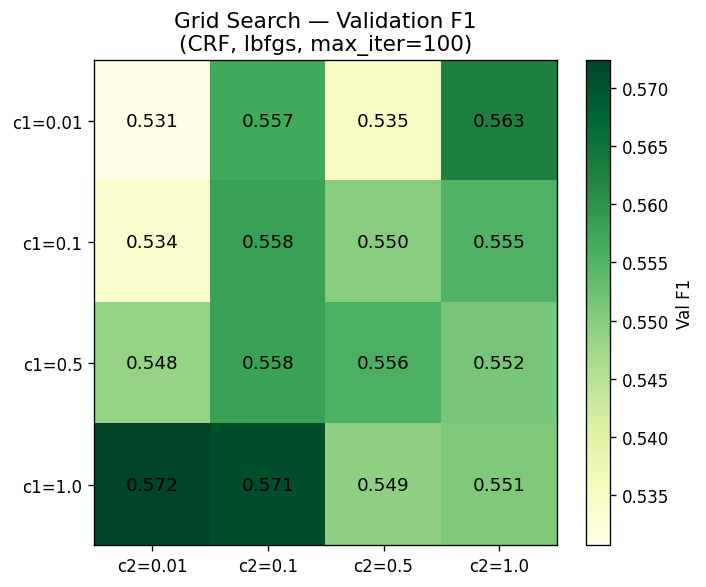

In [8]:
# Visualise grid search heatmap
grid_df = pd.DataFrame(grid_results)
pivot = grid_df.pivot(index='c1', columns='c2', values='val_f1')

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(pivot.values, cmap='YlGn', aspect='auto')
ax.set_xticks(range(len(c2_values)))
ax.set_yticks(range(len(c1_values)))
ax.set_xticklabels([f"c2={v}" for v in c2_values])
ax.set_yticklabels([f"c1={v}" for v in c1_values])
for i in range(len(c1_values)):
    for j in range(len(c2_values)):
        ax.text(j, i, f"{pivot.values[i,j]:.3f}", ha='center', va='center', fontsize=11)
plt.colorbar(im, ax=ax, label='Val F1')
ax.set_title("Grid Search — Validation F1\n(CRF, lbfgs, max_iter=100)")
plt.tight_layout()
plt.show()

### Train Model

In [9]:
# Train with best hyperparameters on train+val
X_trainval = X_train + X_val
y_trainval = y_train + y_val

crf_final = sklearn_crfsuite.CRF(
    algorithm = 'lbfgs',
    c1 = best['c1'],
    c2 = best['c2'],
    max_iterations  = 200,          # more iterations for final model
    all_possible_transitions = True
)
crf_final.fit(X_trainval, y_trainval)

print(f"Final model trained on {len(X_trainval)} resumes")
print(f"c1={best['c1']}, c2={best['c2']}, max_iterations=200")
print(f"Classes: {len(crf_final.classes_)}")

Final model trained on 333 resumes
c1=1.0, c2=0.01, max_iterations=200
Classes: 20


### Evaluate

In [10]:
y_pred_test = crf_final.predict(X_test)

print('=== Test Set Evaluation (seqeval — entity-level) ===')
print(classification_report(y_test, y_pred_test, digits=4))

=== Test Set Evaluation (seqeval — entity-level) ===
                     precision    recall  f1-score   support

       College Name     0.4444    0.4571    0.4507        35
Companies worked at     0.6727    0.5286    0.5920        70
             Degree     0.6471    0.6111    0.6286        36
        Designation     0.6500    0.3514    0.4561        74
      Email Address     0.8889    0.9231    0.9057        26
    Graduation Year     0.6970    0.6216    0.6571        37
           Location     0.2500    0.0909    0.1333        11
               Name     0.9394    0.8857    0.9118        35
             Skills     0.2069    0.1333    0.1622        45
Years of Experience     0.0000    0.0000    0.0000         3

          micro avg     0.6327    0.5000    0.5586       372
          macro avg     0.5396    0.4603    0.4897       372
       weighted avg     0.6126    0.5000    0.5434       372



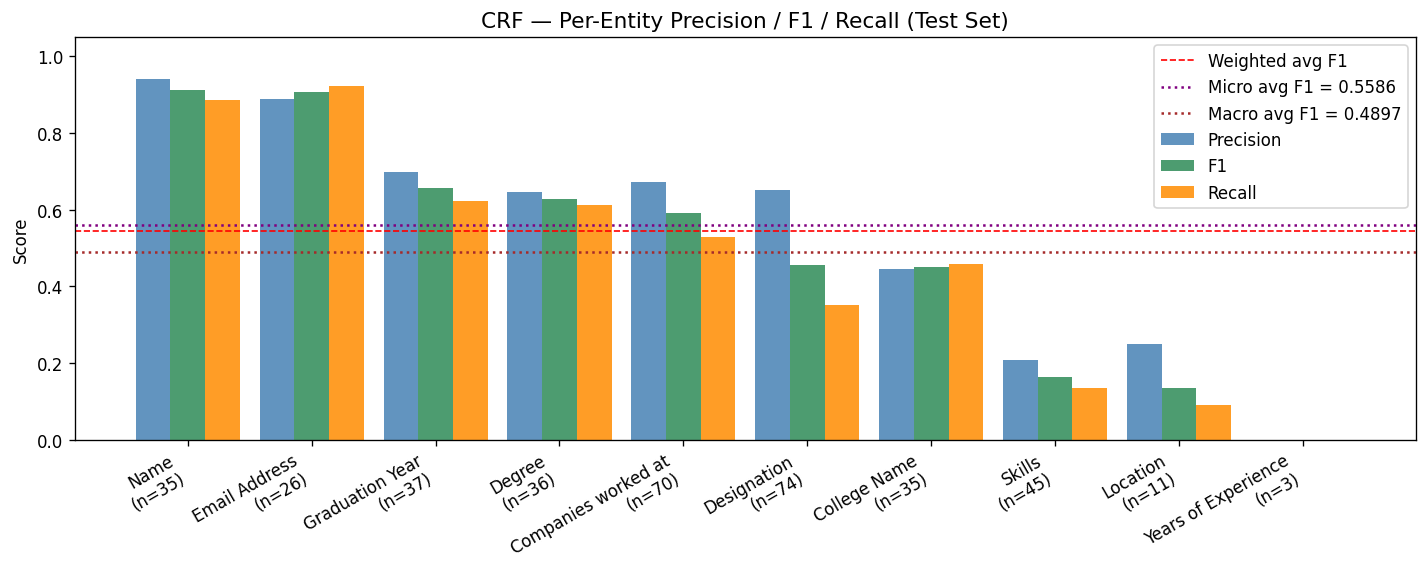

In [15]:
# Per-label F1 bar chart
from seqeval.metrics import classification_report as seq_report
import re as _re

report_str = seq_report(y_test, y_pred_test, digits=4, output_dict=False)
report_dict = seq_report(y_test, y_pred_test, digits=4, output_dict=True)

micro_f1    = report_dict['micro avg']['f1-score']
macro_f1    = report_dict['macro avg']['f1-score']

# Extract per-label rows (exclude micro/macro/weighted avg)
per_label = {
    k: v for k, v in report_dict.items()
    if isinstance(v, dict) and k not in ('micro avg','macro avg','weighted avg')
}

labels_sorted = sorted(per_label, key=lambda k: per_label[k]['f1-score'], reverse=True)
labels_sorted_with_n = [
    f"{k}\n(n={per_label[k]['support']})" 
    for k in labels_sorted
]
f1_scores     = [per_label[k]['f1-score'] for k in labels_sorted]
precision     = [per_label[k]['precision'] for k in labels_sorted]
recall        = [per_label[k]['recall']    for k in labels_sorted]

fig, ax = plt.subplots(figsize=(12, 5))
x = range(len(labels_sorted))
w = 0.28
ax.bar([i - w for i in x], precision, width=w, label='Precision', color='steelblue', alpha=0.85)
ax.bar(list(x),            f1_scores, width=w, label='F1',        color='seagreen',  alpha=0.85)
ax.bar([i + w for i in x], recall,    width=w, label='Recall',    color='darkorange', alpha=0.85)
ax.set_xticks(list(x))
ax.set_xticklabels(labels_sorted_with_n, rotation=30, ha='right')
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('CRF — Per-Entity Precision / F1 / Recall (Test Set)')
ax.axhline(report_dict.get('weighted avg', {}).get('f1-score', 0), color='red', linestyle='--', linewidth=1, label='Weighted avg F1')
ax.axhline(micro_f1, color='purple', linestyle=':', linewidth=1.5, label=f'Micro avg F1 = {micro_f1:.4f}')
ax.axhline(macro_f1, color='brown',  linestyle=':', linewidth=1.5, label=f'Macro avg F1 = {macro_f1:.4f}')
ax.legend()
plt.tight_layout()
plt.show()

### Inference Demo

In [ ]:
# Minimal normalization (must match Preprocessing.ipynb)
_TECH = re.compile(r'[+#]|\d|\.\w|^[A-Z]{1,5}$|^\.[a-z]+')
def _norm(tok):
    is_tech = bool(_TECH.search(tok))
    t = unicodedata.normalize('NFKD', tok).encode('ascii','ignore').decode('ascii').lower()
    t = re.sub(r'^[^\w.#+]+|[^\w.#+]+$', '', t)
    if not t or re.match(r'^[^\w.#+]+$|^[\-\u2013\u2014]+$', t): return None
    return t


def predict_resume(text: str) -> list[tuple[str, str]]:
    # Tokenize
    raw_tokens = [(m.group(), m.start(), m.end()) for m in re.finditer(r'\S+', text)]
    raw_bio    = [(tok, 'O') for tok, _, _ in raw_tokens]   # dummy tags

    # Normalize
    norm_pairs = []
    for tok, tag in raw_bio:
        n = _norm(tok)
        if n: norm_pairs.append((n, tag))

    # Build parallel aligned list
    aligned = align_raw_norm(raw_bio, norm_pairs)
    raw_toks  = [r for r, _, _ in aligned]
    norm_toks = [n for _, n, _ in aligned]

    feats = [
        token_features(raw_toks[i], norm_toks[i], i, raw_toks, norm_toks)
        for i in range(len(aligned))
    ]

    pred_tags = crf_final.predict([feats])[0]
    return list(zip(norm_toks, pred_tags))


def extract_entities(predictions: list[tuple[str, str]]) -> dict:
    entities = {}
    current_toks, current_lbl = [], None
    for tok, tag in predictions:
        if tag.startswith('B-'):
            if current_toks:
                entities.setdefault(current_lbl, []).append(' '.join(current_toks))
            current_toks, current_lbl = [tok], tag[2:]
        elif tag.startswith('I-') and current_toks:
            current_toks.append(tok)
        else:
            if current_toks:
                entities.setdefault(current_lbl, []).append(' '.join(current_toks))
            current_toks, current_lbl = [], None
    if current_toks:
        entities.setdefault(current_lbl, []).append(' '.join(current_toks))
    return entities


# Run on a test resume
sample_content = '\n'.join(
    tok for tok, _ in processed[idx_test[0]]['word_bio_raw']
)
preds = predict_resume(sample_content)
entities = extract_entities(preds)

print('=== Extracted Entities (Test Resume 0) ===')

for lbl, values in entities.items():
    print(f"[{lbl}]")
    for v in values:
        print(f"  • {v[:70]}")
    print()

=== Extracted Entities (Test Resume 0) ===
[Name]
  • mohammed murtuza

[Designation]
  • major incident manager escalation manager
  • manager escalation manager

[Companies worked at]
  • microsoft
  • microsoft

[Skills]
  • range of software hardware and connectivity issues. excel in asking pr
  • 4 .1 lync 2010 server sap srm tools servicenow microsoft icm send word



### Save Model

In [14]:
# Save trained CRF model
model_save = Path('./model_result')
model_save.mkdir(exist_ok=True)
with open(model_save/ 'crf_model.pkl', 'wb') as f:
    pickle.dump(crf_final, f)

# Save test predictions for later comparison across all 7 models
results = {
    'model'          : 'CRF',
    'best_c1'        : best['c1'],
    'best_c2'        : best['c2'],
    'val_f1'         : best['val_f1'],
    'test_f1'        : f1_score(y_test, y_pred_test),
    'test_f1_micro'  : report_dict['micro avg']['f1-score'],
    'test_f1_macro'  : report_dict['macro avg']['f1-score'],
    'test_precision' : precision_score(y_test, y_pred_test),
    'test_recall'    : recall_score(y_test, y_pred_test),
    'y_test'         : y_test,
    'y_pred'         : y_pred_test,
    'idx_test'       : idx_test,
}
with open(model_save / 'results_crf.pkl', 'wb') as f:
    pickle.dump(results, f)

print("Model saved -> data/crf_model.pkl")
print("Results saved -> data/results_crf.pkl")
print()
print("=== Final CRF Scores ===")
print(f"Val  F1       : {best['val_f1']:.4f}")
print(f"Test F1       : {results['test_f1']:.4f}")
print(f"Tes Micro F1  : {results['test_f1_micro']:.4f}")
print(f"Tes Macro F1  : {results['test_f1_macro']:.4f}")
print(f"Test Precision: {results['test_precision']:.4f}")
print(f"Test Recall   : {results['test_recall']:.4f}")

Model saved -> data/crf_model.pkl
Results saved -> data/results_crf.pkl

=== Final CRF Scores ===
Val  F1       : 0.5724
Test F1       : 0.5586
Tes Micro F1  : 0.5586
Tes Macro F1  : 0.4897
Test Precision: 0.6327
Test Recall   : 0.5000
